In [45]:
# importy
import os

import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchinfo import summary

from datasets import load_dataset, concatenate_datasets

from PIL import Image

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tqdm import tqdm

torch.backends.cudnn.benchmark = True

In [46]:
# load + split datasetów
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classnames = ["bottle", "pen", "flashlight"]
class_to_idx = {c: i for i, c in enumerate(classnames)}
num_classes = len(classnames)

In [47]:
os.environ["HF_HUB_DISABLE_XET"] = "1"

def load_and_label(dataset_name, label_name, seed=42, data_dir=None):
    if data_dir:
        ds = load_dataset("imagefolder", data_dir=data_dir)
        base = ds["train"]
    else:
        ds = load_dataset(
            dataset_name,
            download_mode="reuse_dataset_if_exists"
        )
        base = ds["train"]

    def add_label(example):
        example["label"] = class_to_idx[label_name]
        return example

    base = base.map(add_label)

    train_val = base.train_test_split(test_size=0.25, seed=seed)
    val_test = train_val["test"].train_test_split(test_size=0.33, seed=seed)

    return {
        "train": train_val["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    }

In [48]:
# https://huggingface.co/datasets/cuongdtdg/plastic_bottle
bottles = load_and_label("cuongdtdg/plastic_bottle", "bottle")
pens = load_and_label("assets/pen", "pen")
flashlights = load_and_label("assets/flashlight", "flashlight")

Resolving data files:   0%|          | 0/2358 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1492 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1450 [00:00<?, ?it/s]

In [49]:
# merge
train_ds = concatenate_datasets([
    bottles["train"],
    pens["train"],
    flashlights["train"]
])

val_ds = concatenate_datasets([
    bottles["validation"],
    pens["validation"],
    flashlights["validation"]
])

test_ds = concatenate_datasets([
    bottles["test"],
    pens["test"],
    flashlights["test"]
])

In [50]:
class Letterbox:
    def __init__(self, size=32, fill=0):
        self.size = size
        self.fill = fill

    def __call__(self, img: Image.Image):
        w, h = img.size
        target_size = self.size

        # skala (zachowanie proporcji)
        scale = min(target_size / w, target_size / h)
        new_w = int(w * scale)
        new_h = int(h * scale)

        img = img.resize((new_w, new_h), Image.BILINEAR)

        # tworzymy pusty canvas
        new_img = Image.new("RGB", (target_size, target_size), (self.fill, self.fill, self.fill))

        # wklejanie na środek
        paste_x = (target_size - new_w) // 2
        paste_y = (target_size - new_h) // 2

        new_img.paste(img, (paste_x, paste_y))

        return new_img

In [51]:
# transformacje
train_transform = transforms.Compose([
    Letterbox(192),
    transforms.RandomRotation(50),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        shear=5,
        scale=(0.85, 1.15)
    ),
    transforms.ColorJitter(
    brightness=0.3,
    contrast=0.3,
    saturation=0.2
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    Letterbox(192),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])

In [52]:
# dataset wrapper
class HFImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]

        image = item["image"]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(np.array(image))

        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [53]:
# dataloader
train_loader = DataLoader(
    HFImageDataset(train_ds, train_transform),
    batch_size=16,
    shuffle=True,
    num_workers=12,
    persistent_workers=True,
    pin_memory=True
)

val_loader = DataLoader(
    HFImageDataset(val_ds, test_transform),
    batch_size=16,
    num_workers=12,
    persistent_workers=True,
    pin_memory=True
)

test_loader = DataLoader(
    HFImageDataset(test_ds, test_transform),
    batch_size=16,
    num_workers=12,
    persistent_workers=True,
    pin_memory=True
)

In [54]:
# CNN
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.Dropout(0.05),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.Dropout(0.1),
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),
        )

        self.conv5 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),
        )

        self.conv6 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(128, 256),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)

        x = self.pool(x)
        x = x.view(x.size(0), -1)

        return self.fc(x)

In [55]:
# model + loss + optimizer
model = CNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1.2e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=7,
)

summary(model, input_size=(1, 3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 256, 256]         --
│    └─Conv2d: 2-1                       [1, 32, 256, 256]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 256, 256]         64
│    └─SiLU: 2-3                         [1, 32, 256, 256]         --
│    └─Dropout: 2-4                      [1, 32, 256, 256]         --
├─Sequential: 1-2                        [1, 32, 256, 256]         --
│    └─Conv2d: 2-5                       [1, 32, 256, 256]         9,248
│    └─BatchNorm2d: 2-6                  [1, 32, 256, 256]         64
│    └─SiLU: 2-7                         [1, 32, 256, 256]         --
│    └─Dropout: 2-8                      [1, 32, 256, 256]         --
├─Sequential: 1-3                        [1, 64, 128, 128]         --
│    └─Conv2d: 2-9                       [1, 64, 256, 256]         18,496
│    └─

In [56]:
# trening
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    seen = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(dim=1)

        correct += preds.eq(y).sum().item()
        seen += y.size(0)

        acc = correct / seen

        loop.set_postfix(
            loss=loss.item(),
            acc=f"{acc:.4f}"
        )

    return total_loss / len(loader), correct / len(loader.dataset)

In [57]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    seen = 0

    loop = tqdm(loader, desc="Validation", leave=False)

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        out = model(x)

        loss = criterion(out, y)

        bs = x.size(0)

        total_loss += loss.item() * bs

        preds = out.argmax(dim=1)

        correct += (preds == y).sum().item()
        seen += bs

        acc = correct / seen

        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{acc:.4f}"
        )

    return total_loss / seen, correct / seen

In [58]:
# training loop
epochs = 100

train_history = []
val_history = []

# --- early stopping ---
best_val_loss = float("inf")
patience = 12
counter = 0

for epoch in range(epochs):

    # --- train ---
    train_loss, train_acc = train_one_epoch(model, train_loader)

    # --- val ---
    val_loss, val_acc = evaluate(model, val_loader)

    train_history.append((train_loss, train_acc))
    val_history.append((val_loss, val_acc))

    # --- LR tracking (before step) ---
    old_lr = optimizer.param_groups[0]["lr"]

    # --- scheduler step ---
    scheduler.step(val_loss)

    # --- LR tracking (after step) ---
    new_lr = optimizer.param_groups[0]["lr"]

    if new_lr != old_lr:
        print(f"--- LR zmieniony: {old_lr:.6f} → {new_lr:.6f} ---")

    # --- early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        if val_acc > 0.82: # slightly better for SSD lifespan and doesn't spam log messages at the very beginning
            print("--- MODEL ZAPISANY ---")
            torch.save(model.state_dict(), "assets/best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print(f"--- Early stopping: brak poprawy przez {patience} epok ---")
        break

    # --- print epoch summary ---
    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"train acc {train_acc:.5f} train loss {train_loss:.5f} | "
        f"val acc {val_acc:.5f} val loss {val_loss:.5f} | "
        f"lr {new_lr:.6f}"
    )

Epoch 1/100 | train acc 0.61877 train loss 0.84962 | val acc 0.69109 val loss 0.71816 | lr 0.001200


Epoch 2/100 | train acc 0.67740 train loss 0.73724 | val acc 0.68658 val loss 0.71471 | lr 0.001200


Epoch 3/100 | train acc 0.67690 train loss 0.72156 | val acc 0.68320 val loss 0.69849 | lr 0.001200


Epoch 4/100 | train acc 0.68973 train loss 0.71862 | val acc 0.65840 val loss 0.79117 | lr 0.001200


Epoch 5/100 | train acc 0.70533 train loss 0.69345 | val acc 0.71026 val loss 0.73173 | lr 0.001200


...

Epoch 96/100 | train acc 0.91495 train loss 0.23076 | val acc 0.91883 val loss 0.26031 | lr 0.000300


Epoch 97/100 | train acc 0.90916 train loss 0.24426 | val acc 0.90981 val loss 0.27677 | lr 0.000300


Epoch 98/100 | train acc 0.91017 train loss 0.24247 | val acc 0.90981 val loss 0.26549 | lr 0.000300


Epoch 99/100 | train acc 0.91142 train loss 0.24389 | val acc 0.91657 val loss 0.25546 | lr 0.000300


Epoch 100/100 | train acc 0.90287 train loss 0.25153 | val acc 0.90755 val loss 0.25520 | lr 0.000300


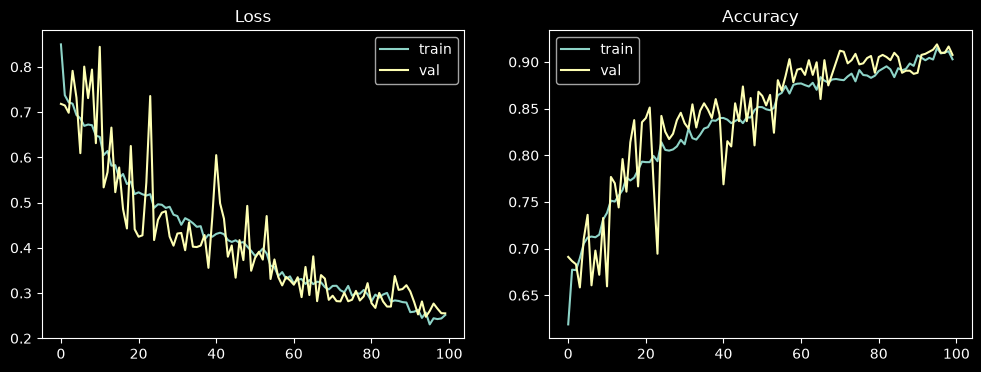

In [59]:
# wykresy
train_loss = [x[0] for x in train_history]
val_loss = [x[0] for x in val_history]

train_acc = [x[1] for x in train_history]
val_acc = [x[1] for x in val_history]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

Val Loss: 0.2253
Val Accuracy: 0.9112


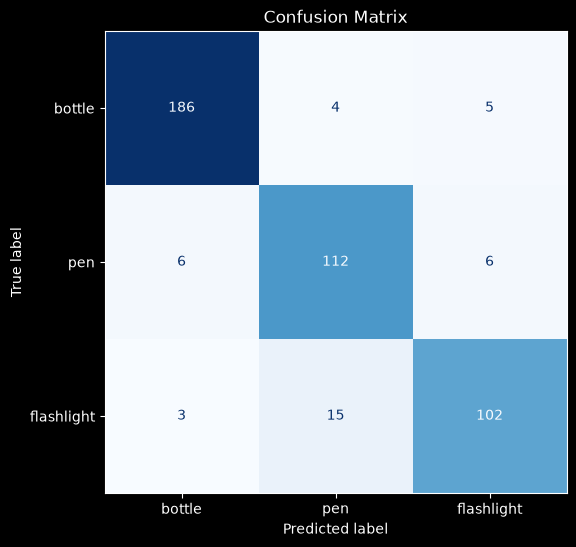

In [60]:
# confusion matrix
# wczytanie modelu
model.load_state_dict(
    torch.load("assets/best_model.pth", map_location=device)
)

all_preds = []
all_true = []
val_loss = 0.0
n_samples = 0

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        out = model(x)

        loss = criterion(out, y)
        batch_size = x.size(0)

        val_loss += loss.item() * batch_size
        n_samples += batch_size

        preds = out.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

val_loss /= n_samples
val_accuracy = (all_preds == all_true).mean()

print(f"Val Loss: {val_loss:.4f}")
print(f"Val Accuracy: {val_accuracy:.4f}")

cm = confusion_matrix(all_true, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=classnames)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.show()